# First-order reversal curve processing with PmagPy

This notebook develops a FORC diagram from the measured reversal curves, one processing decision at a time. It uses the `pmagpy.forc` module and compares the two published local-regression approaches that underpin modern FORC processing:

- Harrison and Feinberg (2008) nearest-neighbor LOESS, the method introduced with FORCinel.
- Egli (2013) VARIFORC, which varies horizontal and vertical smoothing independently.

The module's workflow, `run_forc_pipeline` interface, output organization, and final color palette follow Maxwell Brown's **FORCme** Python package. The data processing in this package is independently tied to the published equations and the FORCinel 3.08 procedure, which is different from FORCme's fixed-ellipse smoothing strategy.

| Program component | Primary provenance | PmagPy implementation |
|---|---|---|
| Staged preparation and one-call/batch workflow | FORCme | `run_forc_pipeline`, with auditable raw, conditioned, processed, and result stages |
| FORC curve plotting and final palette | FORCme | FORCme-compatible plotting name and exact green-red version-2 color stops |
| Constant isotropic smoothing | Harrison and Feinberg (2008) / FORCinel | nearest-neighbor quadratic LOESS with tricube weights |
| Variable anisotropic smoothing | Egli (2013) / FORCinel 3.08 | rectangular variable smoothing and Egli's continuous edge weights |
| Calibration parsing, drift, and baseline safeguards | Published/FORCinel behavior plus validation | retains calibration blocks and prevents unsupported baseline extrapolation |

## Learning objectives

1. Recognize the reversal field, measurement field, coercivity coordinate, and interaction/bias coordinate.
2. Apply calibration-drift and endpoint corrections deliberately.
3. Compare constant isotropic and variable anisotropic local regression.
4. Use uncertainty and signal-to-noise maps to distinguish stable structure from visually attractive noise.
5. Extract a reproducible one-dimensional FORC profile.

## Interactive synthetic FORC experiment

Use **Play** or the slider below to step through a synthetic FORC acquisition. The left panel adds measured reversal curves in acquisition order. For every animation frame, the right panel recalculates the local quadratic regression using only the curves acquired up to that point; it is not simply revealing a finished image. As progressively lower reversal fields are measured, the supported area in $(H_c,H_u)$ space expands and the two synthetic coercivity populations become resolved.

The synthetic sample is an ensemble of rectangular hysterons with two coercivity populations and a narrow distribution of bias fields. A dense ensemble, 2 mT field sampling, and low synthetic measurement noise keep the curves smooth so the acquisition geometry is easy to see. It is deliberately simple: the animation explains sampling geometry and numerical construction, not the full physics of interacting natural particles.

In [1]:
from pathlib import Path
import sys

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from pmagpy import forc

notebook_dir = Path.cwd()
if notebook_dir.name != "FORC_notebooks":
    candidate = notebook_dir / "FORC_notebooks"
    if candidate.exists():
        notebook_dir = candidate
pmag_checkout = notebook_dir.parents[1] / "PmagPy"
if pmag_checkout.exists():
    sys.path.insert(0, str(pmag_checkout))


def make_synthetic_forcs(random_seed=7, n_hysterons=12000, noise_std=0.0005):
    '''Create smooth, lightly noise-perturbed two-component synthetic FORCs.'''
    rng = np.random.default_rng(random_seed)
    first_count = int(0.68 * n_hysterons)
    coercivity = np.concatenate([
        rng.normal(0.028, 0.005, first_count),
        rng.normal(0.057, 0.008, n_hysterons - first_count),
    ])
    coercivity = np.clip(coercivity, 0.006, None)
    bias = rng.normal(0.0, 0.007, n_hysterons)
    down_switch = bias - coercivity
    up_switch = bias + coercivity

    reversal_fields = np.linspace(0.04, -0.12, 33)
    fields, moments, curves, sequences = [], [], [], []
    for curve_number, reversal in enumerate(reversal_fields):
        field = np.arange(reversal, 0.1201, 0.002)
        switched_down = reversal <= down_switch
        state = np.where(
            switched_down[:, None] & (field[None, :] < up_switch[:, None]),
            -1.0,
            1.0,
        )
        moment = state.mean(axis=0) + 0.08 * field
        moment += rng.normal(0.0, noise_std, moment.size)
        fields.append(field)
        moments.append(moment)
        curves.append(np.full(field.size, curve_number, dtype=int))
        sequences.append(np.full(field.size, curve_number, dtype=float))

    return forc.ForcData(
        field=np.concatenate(fields),
        moment=np.concatenate(moments),
        curve=np.concatenate(curves),
        reversal_field=reversal_fields,
        sequence=np.concatenate(sequences),
        curve_sequence=np.arange(reversal_fields.size, dtype=float),
        calibration_field=np.array([], dtype=float),
        calibration_moment=np.array([], dtype=float),
        calibration_sequence=np.array([], dtype=float),
        metadata={},
        source="synthetic two-component hysteron ensemble",
    )


def subset_synthetic_forcs(data, curve_count):
    '''Return the first curve_count FORCs with contiguous curve identifiers.'''
    keep = data.curve < int(curve_count)
    return forc.ForcData(
        field=data.field[keep],
        moment=data.moment[keep],
        curve=data.curve[keep],
        reversal_field=data.reversal_field[:curve_count],
        sequence=data.sequence[keep],
        curve_sequence=data.curve_sequence[:curve_count],
        calibration_field=np.array([], dtype=float),
        calibration_moment=np.array([], dtype=float),
        calibration_sequence=np.array([], dtype=float),
        metadata={},
        source=data.source,
    )


def combined_curve_trace(data):
    '''Combine separate reversal curves into one Plotly trace using gaps.'''
    field, moment = [], []
    for curve_number in range(data.n_curves):
        select = data.curve == curve_number
        field.extend((data.field[select] * 1e3).tolist() + [None])
        moment.extend(data.moment[select].tolist() + [None])
    return field, moment


synthetic = make_synthetic_forcs()
frame_counts = list(range(6, synthetic.n_curves + 1, 2))
if frame_counts[-1] != synthetic.n_curves:
    frame_counts.append(synthetic.n_curves)

animation_results = []
for curve_count in frame_counts:
    partial = subset_synthetic_forcs(synthetic, curve_count)
    result = forc.calculate_forc(
        partial,
        method="variforc",
        sc0=4,
        sc1=8,
        sb0=4,
        sb1=8,
        lambda_c=0.05,
        lambda_b=0.05,
        output_step=1,
        error_method=None,
    )
    animation_results.append((partial, result))

final_rho = animation_results[-1][1].rho
color_limit = float(np.nanpercentile(np.abs(final_rho[np.isfinite(final_rho)]), 99))


def animation_frame_data(partial, result):
    '''Create the raw-curve and calculated-rho traces for one frame.'''
    field, moment = combined_curve_trace(partial)
    return [
        go.Scatter(x=field, y=moment, mode="lines", line=dict(color="#303030", width=1)),
        go.Heatmap(
            x=result.hc[0, :] * 1e3,
            y=result.hu[:, 0] * 1e3,
            z=result.rho,
            colorscale="RdBu_r",
            zmin=-color_limit,
            zmax=color_limit,
            zmid=0,
            colorbar=dict(title="rho"),
        ),
    ]


first_partial, first_result = animation_results[0]
figure = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Acquired reversal curves", "FORC diagram calculated so far"),
    horizontal_spacing=0.12,
)
first_traces = animation_frame_data(first_partial, first_result)
figure.add_trace(first_traces[0], row=1, col=1)
figure.add_trace(first_traces[1], row=1, col=2)

figure.frames = [
    go.Frame(
        name=str(curve_count),
        data=animation_frame_data(partial, result),
        traces=[0, 1],
        layout=go.Layout(title_text=f"Synthetic FORC experiment: {curve_count} of {synthetic.n_curves} curves acquired"),
    )
    for curve_count, (partial, result) in zip(frame_counts, animation_results)
]

figure.update_layout(
    title=f"Synthetic FORC experiment: {frame_counts[0]} of {synthetic.n_curves} curves acquired",
    height=520,
    showlegend=False,
    updatemenus=[dict(
        type="buttons",
        direction="left",
        x=0.1,
        y=-0.12,
        buttons=[
            dict(label="Play", method="animate", args=[None, {"frame": {"duration": 280, "redraw": True}, "fromcurrent": True}]),
            dict(label="Pause", method="animate", args=[[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]),
        ],
    )],
    sliders=[dict(
        active=0,
        x=0.32,
        y=-0.10,
        len=0.62,
        currentvalue=dict(prefix="FORCs acquired: "),
        steps=[
            dict(label=str(count), method="animate", args=[[str(count)], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}}])
            for count in frame_counts
        ],
    )],
)
figure.update_xaxes(title_text="Applied field (mT)", range=[-125, 125], row=1, col=1)
figure.update_yaxes(title_text="Normalized moment", range=[-1.1, 1.1], row=1, col=1)
figure.update_xaxes(title_text="Coercivity Hc (mT)", range=[0, 100], row=1, col=2)
figure.update_yaxes(title_text="Interaction field Hu (mT)", range=[-55, 55], row=1, col=2)
figure.show()

## 1. What a FORC measurement samples

A conventional hysteresis loop records one path around the major loop. It is useful, but it compresses the switching behavior of many magnetic components into a single curve. A first-order reversal curve (FORC) measurement adds a second control variable: it records many return paths that begin at different reversal fields. Together, those paths reveal how the response on the return sweep depends on the sample's magnetic history.

### Building the family of reversal curves

One FORC is acquired in three steps:

1. Drive the sample to a large positive field so that its magnetic moments are close to positive saturation.
2. Decrease the field, without recording the FORC, to a chosen reversal field $H_r$. This sets the magnetic state from which the return curve begins.
3. Increase the applied field $H$ back toward positive saturation and record the moment $M$ at a sequence of field values.

The procedure is repeated with progressively lower values of $H_r$. Every measured moment is therefore written as $M(H_r,H)$: $H_r$ identifies the curve and stores its magnetic history, while $H$ identifies the measurement position along that curve. Because measurements on a return sweep satisfy $H\geq H_r$, the sampled points occupy a triangular region rather than a complete rectangle. Stacking all of the curves produces a discrete two-dimensional magnetization surface.

### From the magnetization surface to a FORC distribution

The magnetization surface itself is dominated by the large, smooth change from negative to positive moment. The FORC calculation is designed to expose the smaller irreversible changes hidden within that surface. It asks: **how does the slope of a return curve change when the reversal field is changed?** Mathematically, that question is answered by the mixed second derivative $\partial^2M/(\partial H_r\,\partial H)$.

A contribution that depends only on the measurement field $H$ has the same slope on every reversal curve and ideally disappears from this mixed derivative. A contribution associated with irreversible switching changes as $H_r$ changes and produces structure in the FORC distribution. Positive peaks and ridges commonly mark concentrations of irreversible switching behavior; negative regions can be real, but can also arise from interactions, overlapping components, boundaries, or processing artifacts. A FORC diagram is therefore not automatically a literal particle-size or coercivity histogram. That direct interpretation is valid only for restrictive idealized hysteron models.

Following the normalization used by Egli (2013) and current FORCinel, the distribution is

$$
\rho(H_r,H)=-\frac{1}{2}\frac{\partial^2 M}{\partial H_r\,\partial H}.
$$

The minus sign makes the main irreversible switching populations positive under the usual FORC measurement convention. Some publications omit the factor of $1/2$, so absolute amplitudes should only be compared after checking the convention. PmagPy uses the equation above.

### Rotating into coercivity and interaction-field coordinates

FORC diagrams are usually displayed after rotating the $(H_r,H)$ axes by 45 degrees:

| Symbol | Definition | Interpretation |
|---|---:|---|
| $H_r$ | reversal field | identifies the return curve and its prior magnetic history |
| $H$ | applied field on the return sweep | identifies a measurement along that curve |
| $H_c$ | $(H-H_r)/2$ | coercivity-like coordinate; half-distance between switching fields |
| $H_u$ | $(H+H_r)/2$ | bias or interaction-field-like coordinate; midpoint between switching fields |

The inverse relations are $H=H_u+H_c$ and $H_r=H_u-H_c$. Since $H\geq H_r$ during measurement, $H_c$ is non-negative. In an ideal ensemble of non-interacting rectangular hysterons, $H_c$ equals the hysteron's coercive field and $H_u$ equals its bias field. Real magnetic particles are more complicated, so these axes should be read as useful switching coordinates rather than exact microscopic measurements. A narrow ridge near $H_u=0$ is consistent with little net bias; vertical spreading or displacement can reflect interactions, bias fields, or a mixture of components, but the pattern is not unique to a single physical cause.

### Why a local magnetic field shifts an observed switching field

The instrument reports the field it applies, but a magnetic switching unit responds to the total effective field at its location. In the simplest constant-bias picture,

$$
H_{\mathrm{effective}}=H_{\mathrm{applied}}+H_{\mathrm{local}}.
$$

Suppose a square-loop switching unit intrinsically switches down when its effective field reaches $-H_0$ and switches up when it reaches $+H_0$. The applied fields observed by the instrument are then

$$
H_{\mathrm{down}}=-H_0-H_{\mathrm{local}},
\qquad
H_{\mathrm{up}}=+H_0-H_{\mathrm{local}}.
$$

The same local field shifts both observed switching fields by the same amount. It does not change their separation in this ideal example:

$$
H_c=\frac{H_{\mathrm{up}}-H_{\mathrm{down}}}{2}=H_0,
\qquad
H_u=\frac{H_{\mathrm{up}}+H_{\mathrm{down}}}{2}=-H_{\mathrm{local}}.
$$

For a numerical example, take $H_0=20$ mT. With no local field, the unit switches at $-20$ and $+20$ mT, giving $(H_c,H_u)=(20,0)$ mT. If its local field is $-5$ mT, the applied field must satisfy $H_{\mathrm{effective}}=H_{\mathrm{applied}}-5$ mT. Downward switching is then observed at $-15$ mT and upward switching at $+25$ mT. Their separation is still 40 mT, so $H_c$ remains 20 mT, but their midpoint has moved to $H_u=+5$ mT. The unit has not become harder to switch; the external field scale has been offset because the applied field must compensate for the local field.

The sign deserves care. With the field convention used above, a positive plotted $H_u$ corresponds to a negative field added locally to the applied field. It is often safest to describe $H_u$ first as the **observed midpoint or bias of the switching pair**, and only then relate its sign to a physical local field using the stated convention.

### Are we describing one particle or a group?

The rectangular hysteron used in this explanation is a switching unit, not automatically one literal grain. It may approximate a single-domain grain, a coherently switching region within a larger grain, or a coupled group that behaves as one unit. A measured FORC diagram adds the responses of very many such units. Neighboring remanent moments, demagnetizing fields, exchange coupling, or exchange bias can supply local fields. If different units experience different biases, their FORC signal spreads vertically along $H_u$. If the biases have a nonzero average, a feature can shift above or below $H_u=0$.

Real interactions are often more complicated than a constant offset. A neighbor's moment can reverse during the measurement, changing the local field while the target unit is switching. Such state-dependent interactions can alter widths and shapes in both $H_c$ and $H_u$, so vertical spreading is interaction-like evidence rather than a unique quantitative interaction measurement.

### What one ideal square-loop single-domain grain produces

Consider an isolated single-domain grain measured along its easy axis, with a perfectly square loop and switching fields $-H_k$ and $+H_k$. If a reversal field does not reach $-H_k$, the grain remains at $+M_s$ and its return FORC is flat. Once $H_r$ reaches or passes $-H_k$, the grain is at $-M_s$ at the start of the return sweep; it stays there until $H$ reaches $+H_k$, where it jumps directly back to $+M_s$.

The FORC derivative locates the intersection of those two switching conditions. For this unbiased grain,

$$
(H_c,H_u)=\left(\frac{H_k-(-H_k)}{2},\frac{H_k+(-H_k)}{2}\right)=(H_k,0).
$$

The ideal mathematical result is one positive delta-function point at coercivity $H_k$ and $H_u=0$, not an extended ridge. Finite field spacing and smoothing turn that point into a small spot. Many identical non-interacting grains strengthen the same spot; a range of coercivities broadens it horizontally along $H_c$; a range of switching biases broadens it vertically along $H_u$. Misaligned or non-ideal single-domain grains can also have reversible rotation and need not produce a perfectly square loop or a perfect point.

### Why this is not the paramagnetic contribution

A paramagnetic background approximately follows $M_{\mathrm{para}}=\chi H$. It responds reversibly to the current applied field, has no switching threshold, and carries no reversal-field memory. It therefore tilts all FORCs in a similar way but does not shift a hysteretic switching pair. Because it depends only on $H$, its ideal mixed derivative with respect to $H_r$ and $H$ is zero. A magnetic interaction or bias field is different: it changes the effective field experienced by an irreversible switching unit and can therefore change the applied field at which the jump is observed.

Using these rotated coordinates, the same FORC distribution can be written as

$$
\rho(H_c,H_u)=\frac{1}{8}\left(\frac{\partial^2M}{\partial H_c^2}-\frac{\partial^2M}{\partial H_u^2}\right).
$$

This form shows that $\rho$ measures a particular difference between curvature along the coercivity direction and curvature along the interaction-field direction.

### How the derivative is calculated from discrete, noisy data

The instrument does not measure a continuous surface; it measures separated points with finite precision. Directly taking second differences between adjacent points would strongly amplify measurement noise and produce a speckled diagram. FORC processing instead estimates a small smooth surface around each output location and differentiates that fitted surface analytically.

At a target point $(H_{c,0},H_{u,0})$, nearby measurements are expressed in centered coordinates $x=(H_c-H_{c,0})/\delta H$ and $y=(H_u-H_{u,0})/\delta H$, where $\delta H$ is the nominal field step. A weighted quadratic surface is then fitted:

$$
P(x,y)=a_0+a_1x+a_2x^2+a_3y+a_4y^2+a_5xy,
\qquad
\hat\rho=\frac{a_2-a_4}{4\delta H^2}.
$$

The coefficients $a_2$ and $a_4$ describe local curvature along $H_c$ and $H_u$; their difference gives the estimated FORC density $\hat\rho$. The other coefficients allow the local surface to have an offset, slopes, and a tilted cross-term, so ordinary background variation is represented rather than mistaken for curvature. This fit is repeated at every supported output-grid point.

Smoothing is therefore part of the numerical derivative, not merely a cosmetic filter applied to a completed image. A small neighborhood preserves narrow features but leaves more noise. A large neighborhood reduces noise but can broaden, merge, or weaken real features. The main scientific choice in FORC processing is which nearby observations enter each fit and how strongly each one is weighted; the next section compares two published ways to make that choice.

## 2. The two smoothing algorithms

### Harrison-FORCinel LOESS

Harrison and Feinberg (2008) select a fixed number of nearest measured neighbors around every output point. The effective smoothing factor controls that number, and a radial tricube weight

$$w_i=\left[1-(d_i/d_{\max})^3\right]^3$$

downweights distant observations. The neighborhood is isotropic: the same distance scale applies in every direction. It can expand asymmetrically near $H_c=0$ or a data gap, allowing the fit to reach the edge without inventing an extended FORC surface.

### VARIFORC

Egli (2013) selects observations in a rectangle with horizontal half-width $s_c\delta H$ and vertical half-width $s_b\delta H$. A separable edge weight uses all interior observations at full weight and tapers only over the outer field step. The important change is that $s_c$ and $s_b$ vary independently across FORC space.

- Small $s_b$ near $H_u=0$ preserves a narrow central ridge.
- Larger $s_c$ at high coercivity suppresses noise without broadening that ridge vertically.
- Small $s_c$ near $H_c=0$ can preserve a vertical ridge.

The defaults below, $(s_{c,0},s_{b,0})=(3,3)$, $(s_{c,1},s_{b,1})=(7,7)$, and $\lambda_c=\lambda_b=0.07$, correspond to Egli's example for a diagram that may contain both central and vertical ridges. They are informed starting values, not universal constants.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# When this notebook is run from a RockmagPy/PmagPy development checkout, use
# the adjacent PmagPy source tree. An installed pmagpy package works unchanged.
notebook_dir = Path.cwd()
if notebook_dir.name != "FORC_notebooks":
    candidate = notebook_dir / "FORC_notebooks"
    if candidate.exists():
        notebook_dir = candidate
pmag_checkout = notebook_dir.parents[1] / "PmagPy"
if pmag_checkout.exists():
    sys.path.insert(0, str(pmag_checkout))

from pmagpy import forc

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 3. Read and audit the measurement file

The walkthrough example is the Baraboo vein-material hematite dataset, a MicroMag hybrid-SI export with 270 FORCs. Calibration observations and FORC blocks alternate in the numeric section. Reading is kept separate from processing so that curve counts, field limits, and units can be checked before any values are changed.

The parser reports field in tesla and retains moment in the file's native unit (normally A m$^2$ here). A mismatch between the header's `NForc` value and the parsed curve count should be investigated before proceeding.

In [3]:
data_path = notebook_dir.parent / "example_data" / "FORC" / "baraboo_vein_material_hematite.txt"
raw = forc.read_forc(data_path)

summary = pd.Series(raw.summary(), name="value")
display(summary.to_frame())

header_nforc = forc.metadata_value(raw.metadata, "NForc")
assert header_nforc is None or int(header_nforc) == raw.n_curves

hc_header = forc.metadata_value(raw.metadata, "Hc2")
hu_header = forc.metadata_value(raw.metadata, "Hb2")
hc_plot_max = 1e3 * hc_header if hc_header is not None else 1e3 * np.nanmax(raw.hc)
hu_plot_max = abs(1e3 * hu_header) if hu_header is not None else 1e3 * np.nanmax(np.abs(raw.hu))

,value
source,/Users/yimingzhang/Github/RockmagPy-notebooks/...
curves,270
measurements,67930
finite_measurements,67930
calibrations,270
field_min_T,-1.245
field_max_T,1.095
reversal_min_T,-1.245
reversal_max_T,0.1
field_step_T,0.005


## 4. Inspect the reversal curves before differentiation

Plotting a subset of raw curves is a fast quality-control step. Look for discontinuous curves, isolated spikes, saturation-range changes, or curve crossings that are unlikely to be physical. A local regression can soften these defects visually while still propagating them into diagonal artifacts in $\rho$.

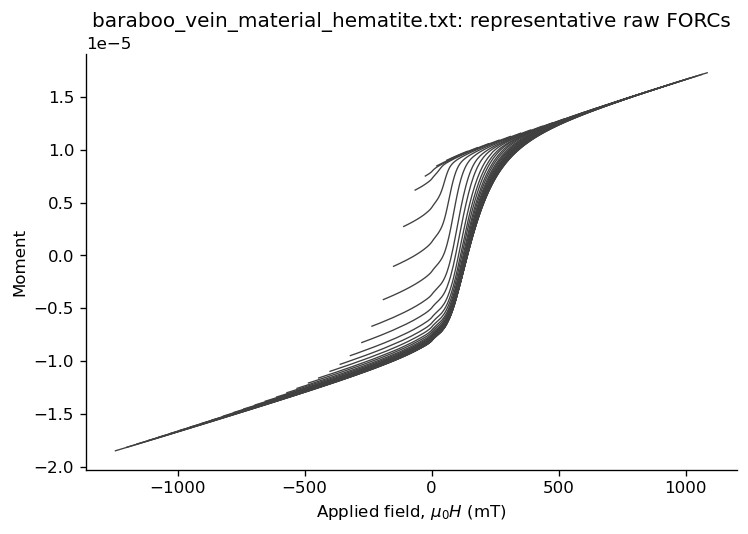

In [4]:
fig, ax = forc.plot_forc_curves(raw, fraction=0.12)
ax.set_title(f"{data_path.name}: representative raw FORCs")
plt.show()

## 5. High-field slope correction

A paramagnetic contribution increases linearly with applied field; a diamagnetic contribution produces a linear slope with the opposite sign. Even after the ferromagnetic component is close to saturation, this background can leave the high-field ends of the FORCs visibly tilted. In the moment units used here, the fitted quantity is a high-field slope with units of moment per tesla. It becomes a conventional volume or mass susceptibility only after the appropriate sample normalization.

Do not interpret this common linear tilt as an $H_u$ interaction-field shift. The slope adds moment continuously as $H$ changes; it does not move a pair of irreversible switching thresholds. An $H_u$ offset instead describes the midpoint of a down-switch/up-switch pair. This is why a paramagnetic slope can be visually prominent in the raw curves while ideally contributing no FORC density.

We estimate the background from the upper 20% of the positive measured-field range. A straight line is fitted separately to every curve containing at least five points in that interval, and the median of the curve-level slopes is used so that one unusual curve cannot dominate the estimate. The corrected curve moment is

$$
M_{\mathrm{corrected}}=M_{\mathrm{measured}}-\chi_{\mathrm{HF}}H.
$$

The before-and-after panels below are an important saturation check: the corrected high-field tails should be approximately horizontal and should not develop systematic curvature. If the tails remain curved, the ferromagnetic component may not be saturated and a linear background should not be over-interpreted as purely paramagnetic or diamagnetic.

This correction is shown as a curve-level diagnostic rather than silently inserted into the FORC calculation. The ideal mixed derivative of a term proportional only to $H$ is zero, and the local quadratic model already contains linear terms. Subtracting the fitted line therefore changes the appearance and background moment of the curves but should not create or remove FORC density. Calibration drift, which can vary with acquisition time and therefore with $H_r$, does not cancel in the same way and is treated next.

,value
high-field cutoff (mT),8.760000e+02
curves included,7.900000e+01
median slope (moment/T),7.621914e-06
slope interquartile range (moment/T),7.022580e-08


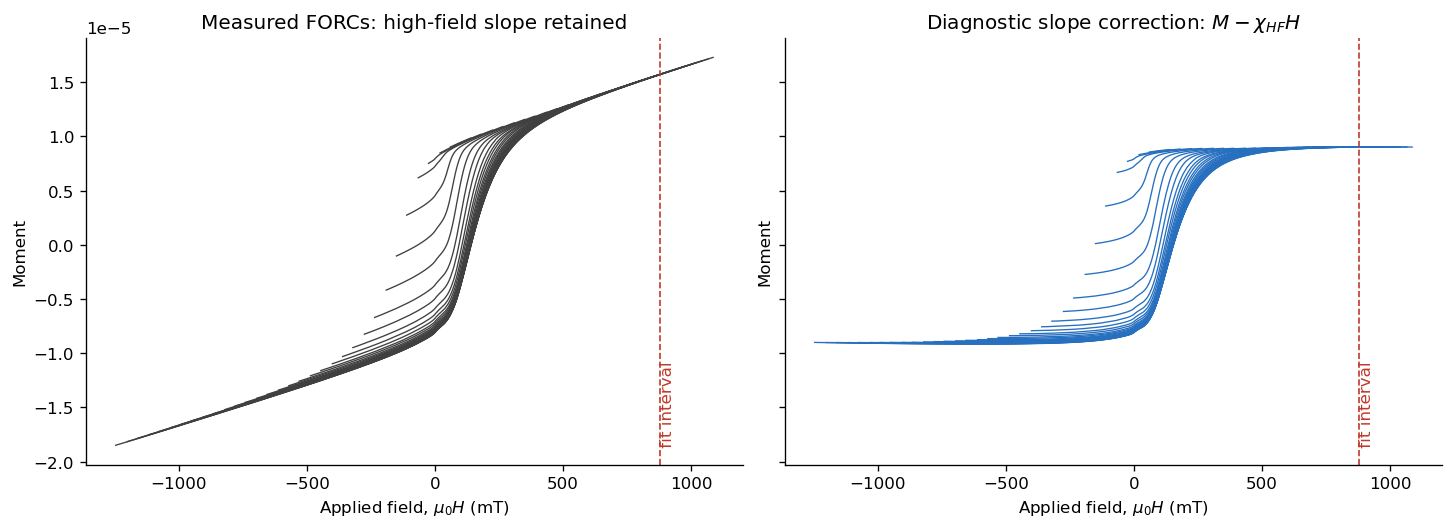

In [5]:
from dataclasses import replace


def correct_high_field_slope(data, high_field_fraction=0.80, min_points=5):
    '''Estimate a robust positive high-field slope and return corrected curves.'''
    high_field_cutoff = high_field_fraction * np.nanmax(data.field)
    fit_rows = []
    for curve_number in range(data.n_curves):
        select = (
            (data.curve == curve_number)
            & (data.field >= high_field_cutoff)
            & np.isfinite(data.moment)
        )
        if np.count_nonzero(select) < min_points:
            continue
        slope, intercept = np.polyfit(data.field[select], data.moment[select], 1)
        fit_rows.append({
            "curve": curve_number,
            "points": int(np.count_nonzero(select)),
            "slope (moment/T)": float(slope),
            "intercept (moment)": float(intercept),
        })

    fits = pd.DataFrame(fit_rows)
    if fits.empty:
        raise ValueError("No curve has enough points in the selected high-field interval.")

    high_field_slope = float(fits["slope (moment/T)"].median())
    metadata = dict(data.metadata)
    metadata["high_field_slope_moment_per_T"] = high_field_slope
    corrected = replace(
        data,
        moment=data.moment - high_field_slope * data.field,
        metadata=metadata,
    )
    return corrected, high_field_slope, high_field_cutoff, fits


slope_corrected, high_field_slope, high_field_cutoff, high_field_fits = (
    correct_high_field_slope(raw)
)

slope_summary = pd.Series({
    "high-field cutoff (mT)": 1e3 * high_field_cutoff,
    "curves included": len(high_field_fits),
    "median slope (moment/T)": high_field_slope,
    "slope interquartile range (moment/T)": (
        high_field_fits["slope (moment/T)"].quantile(0.75)
        - high_field_fits["slope (moment/T)"].quantile(0.25)
    ),
}, name="value")
display(slope_summary.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharex=True, sharey=True, constrained_layout=True)
forc.plot_forc_curves(raw, fraction=0.12, ax=axes[0])
axes[0].set_title("Measured FORCs: high-field slope retained")
forc.plot_forc_curves(slope_corrected, fraction=0.12, ax=axes[1], color="#276FBF")
axes[1].set_title(r"Diagnostic slope correction: $M-\chi_{HF}H$")
for axis in axes:
    axis.axvline(1e3 * high_field_cutoff, color="#C0392B", linestyle="--", linewidth=1.0)
    axis.text(
        1e3 * high_field_cutoff,
        0.03,
        " fit interval",
        color="#C0392B",
        rotation=90,
        va="bottom",
        transform=axis.get_xaxis_transform(),
    )
plt.show()


## 6. Calibration drift

MicroMag FORC protocols interleave measurements at a calibration field. Long-term sensitivity drift changes the scale of an entire curve and should be corrected before taking derivatives.

The sources are not identical here. Active FORCinel 3.08 scales each moment by the first calibration divided by the interpolated calibration. The printed Egli (2013) equation 23 shows the inverse ratio, while FORCme subtracts the calibration change additively. PmagPy uses the active FORCinel behavior by default and exposes the literal alternatives as `egli_equation23` and `additive`, so a reported result is reproducible rather than silently conflating the three conventions.

The result panels below show the measured and smoothed calibration series, the multiplicative correction applied through acquisition time, and representative FORCs before and after correction. The curve-level change can be visually subtle when drift is small, which is why the correction-factor panel is included. Sharp calibration jumps deserve investigation; smoothing them away is not a substitute for rejecting unstable measurements.

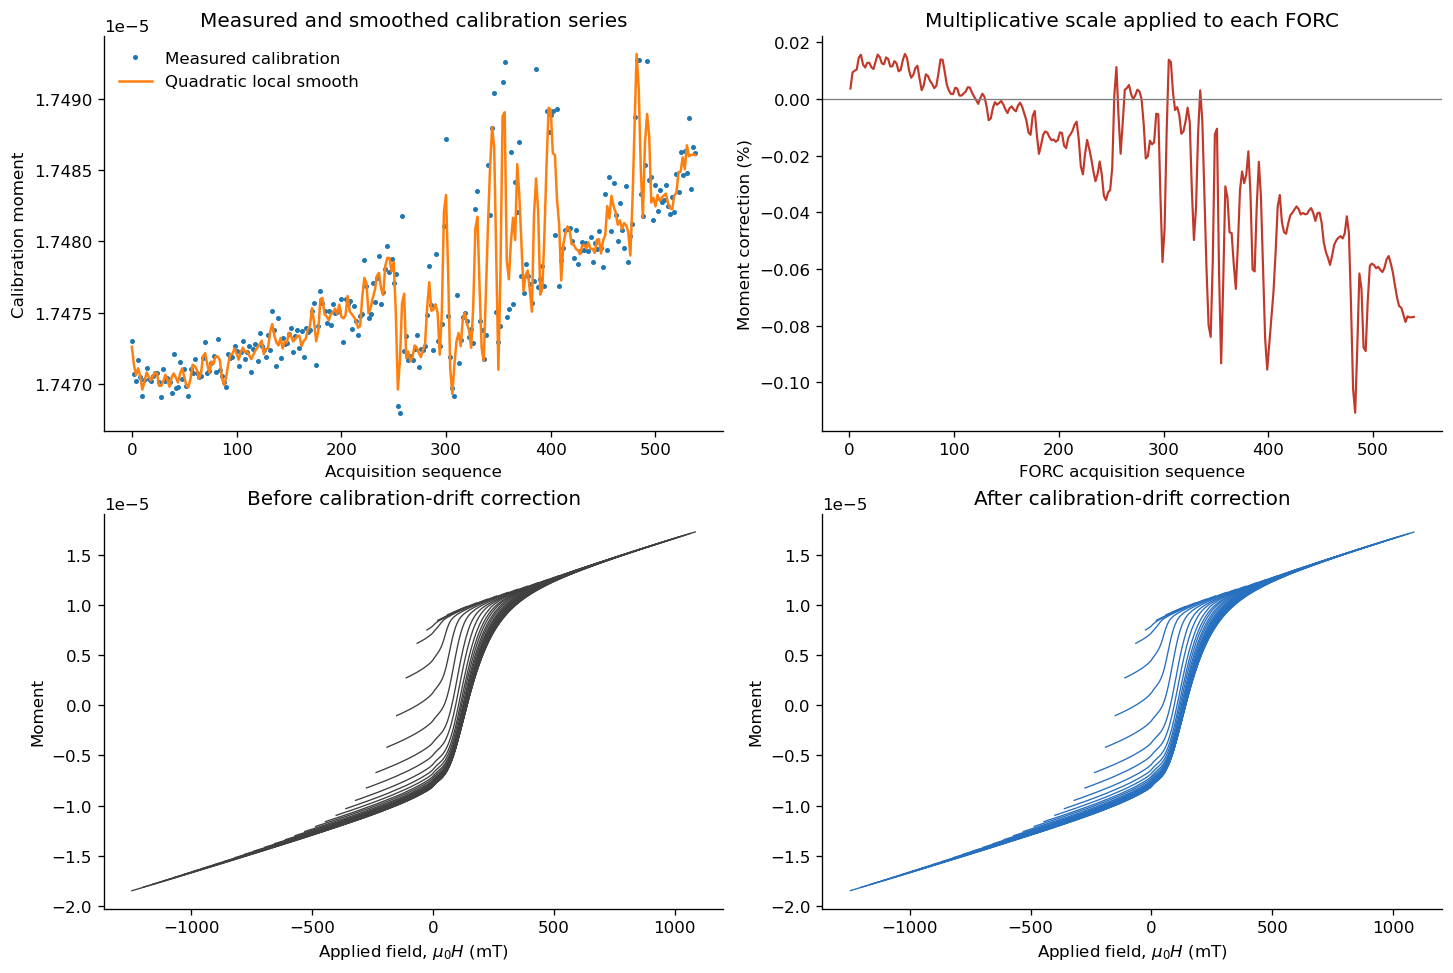

In [6]:
calibration_smooth = forc.smooth_calibrations(raw.calibration_moment, smoothing=2)
drift_corrected = forc.correct_drift(
    raw,
    method="multiplicative",
    interpolation="linear",
    smoothing=2,
)

curve_calibration = np.interp(
    raw.curve_sequence,
    raw.calibration_sequence,
    calibration_smooth,
    left=calibration_smooth[0],
    right=calibration_smooth[-1],
)
curve_scale = calibration_smooth[0] / curve_calibration

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes[0, 0].plot(raw.calibration_sequence, raw.calibration_moment, ".", ms=4, label="Measured calibration")
axes[0, 0].plot(raw.calibration_sequence, calibration_smooth, lw=1.5, label="Quadratic local smooth")
axes[0, 0].set(
    xlabel="Acquisition sequence",
    ylabel="Calibration moment",
    title="Measured and smoothed calibration series",
)
axes[0, 0].legend(frameon=False)

axes[0, 1].plot(raw.curve_sequence, 100 * (curve_scale - 1), color="#C0392B", lw=1.3)
axes[0, 1].axhline(0, color="0.5", lw=0.8)
axes[0, 1].set(
    xlabel="FORC acquisition sequence",
    ylabel="Moment correction (%)",
    title="Multiplicative scale applied to each FORC",
)

forc.plot_forc_curves(raw, fraction=0.12, ax=axes[1, 0])
axes[1, 0].set_title("Before calibration-drift correction")
forc.plot_forc_curves(
    drift_corrected, fraction=0.12, ax=axes[1, 1], color="#276FBF"
)
axes[1, 1].set_title("After calibration-drift correction")
axes[1, 1].set_ylim(axes[1, 0].get_ylim())
plt.show()

## 7. Endpoint and lower-branch choices

The first and last points of a FORC are commonly affected by field sweep-rate changes. The active FORCinel 3.08 procedure excludes both points; FORCme replaces them by linear extrapolation from the interior. Here we use the conservative FORCinel choice and retain the coordinates as masked targets so the local fit can still reach the boundary. The plot below marks the excluded measurements on the longest curve so the operation is visible rather than represented only by a count.

Lower-branch subtraction is **off by default**. It is useful for centering the magnetization surface in some PCA or component-separation workflows, but finite local fits can be affected near data boundaries even though subtracting a function of $H$ alone does not change the ideal mixed derivative.

The implementation details matter because the packages accept somewhat different input layouts. FORCme's current segmentation expects calibration points to be attached to multi-point blocks, and its optional lower-branch reference is the first remaining FORC. Some MicroMag exports instead store calibrations as one-point blocks and begin with a very short high-reversal FORC. FORCinel pools low-reversal curves and permits its quadratic LOESS fit to extend beyond their measured fields. PmagPy retains the FORCme workflow while using a coverage-aware baseline: at every applied field it takes the median of the five lowest-reversal curves that **actually contain that field**, then smooths the resulting one-dimensional baseline. This avoids unsupported constant or long-polynomial extrapolation and the associated high-field tail.

Automatic outlier removal is also deliberately absent from this walkthrough. Diagnose suspect curves from raw data and residual structure, document any exclusions, and then recalculate.

,count
raw finite moments,67930
conditioned finite moments,67391
masked endpoints,539


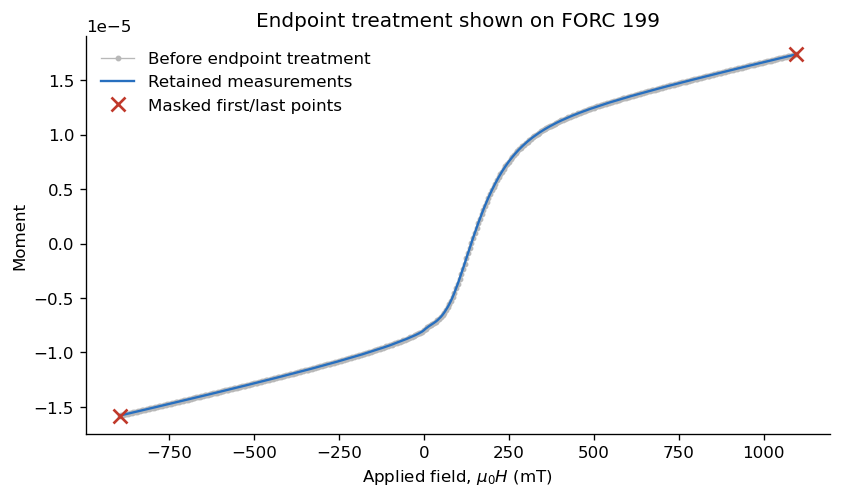

In [7]:
conditioned = forc.adjust_endpoints(drift_corrected, method="drop", n=1)

conditioning = pd.Series({
    "raw finite moments": np.isfinite(raw.moment).sum(),
    "conditioned finite moments": np.isfinite(conditioned.moment).sum(),
    "masked endpoints": np.count_nonzero(~np.isfinite(conditioned.moment)),
})
display(conditioning.to_frame("count"))

curve_lengths = np.bincount(drift_corrected.curve, minlength=drift_corrected.n_curves)
example_curve = int(np.argmax(curve_lengths))
select = drift_corrected.curve == example_curve
dropped = select & ~np.isfinite(conditioned.moment)

fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(
    drift_corrected.field[select] * 1e3,
    drift_corrected.moment[select],
    "o-",
    color="0.72",
    markersize=2.5,
    linewidth=0.8,
    label="Before endpoint treatment",
)
ax.plot(
    conditioned.field[select] * 1e3,
    conditioned.moment[select],
    color="#276FBF",
    linewidth=1.4,
    label="Retained measurements",
)
ax.plot(
    drift_corrected.field[dropped] * 1e3,
    drift_corrected.moment[dropped],
    "x",
    color="#C0392B",
    markersize=8,
    markeredgewidth=1.6,
    label="Masked first/last points",
)
ax.set(
    xlabel=r"Applied field, $\mu_0H$ (mT)",
    ylabel="Moment",
    title=f"Endpoint treatment shown on FORC {example_curve}",
)
ax.legend(frameon=False)
plt.show()

## 8. Calculate both published estimates

Both calculations below use the same corrected measurements, output grid, normalized FORC definition, and HC3 heteroscedasticity-robust error estimator. Their difference therefore isolates the smoothing strategy.

`output_step=1` evaluates every nominal field increment, giving the densest scientific output grid supported by the measured 5 mT field spacing. This increases the number of calculated cells and the run time, but it does not invent measurements between the acquired field values.

In [8]:
variforc_result = forc.calculate_forc(
    conditioned,
    method="variforc",
    sc0=3,
    sc1=7,
    sb0=3,
    sb1=7,
    lambda_c=0.07,
    lambda_b=0.07,
    output_step=1,
    error_method="hc3",
)

loess_result = forc.calculate_forc(
    conditioned,
    method="loess",
    smoothing_factor=3.0,
    output_step=1,
    error_method="hc3",
)

comparison = pd.DataFrame({
    "Harrison LOESS": {
        "finite output cells": np.isfinite(loess_result.rho).sum(),
        "median points per fit": np.nanmedian(loess_result.point_count[loess_result.point_count > 0]),
        "median |rho|/error": np.nanmedian(loess_result.signal_to_noise),
    },
    "VARIFORC": {
        "finite output cells": np.isfinite(variforc_result.rho).sum(),
        "median points per fit": np.nanmedian(variforc_result.point_count[variforc_result.point_count > 0]),
        "median |rho|/error": np.nanmedian(variforc_result.signal_to_noise),
    },
}).T
display(comparison)

,finite output cells,median points per fit,median |rho|/error
Harrison LOESS,34298.0,78.0,0.437853
VARIFORC,34298.0,1007.0,2.119685


## 9. Compare the diagrams

The panels are independently normalized to their maximum absolute amplitude, matching the `pct=100` setting in the current FORCme Baraboo example. This is appropriate for comparing shape and resolution, but **not** for comparing absolute FORC amplitude. For quantitative amplitude, set `normalize=False` and use common color limits.

The display geometry follows the FORCme example's 7 inch width, equal physical field scaling, 150 dpi display resolution, and documented 600 dpi export resolution. The diagrams are stacked on a compact two-row canvas so the wide hematite coercivity range is not squeezed into narrow side-by-side panels. Each colorbar is repositioned after layout to exactly the height of its FORC diagram rather than the full subplot slot.

FORCme additionally uses `display_upsample_factor=2`. We reproduce that visual refinement by linearly interpolating the already calculated $\rho$ grid by a factor of two before plotting. This makes color-cell edges and contours look smoother, but it is display-only: the scientific calculation remains on the measured 5 mT grid and no additional resolution should be inferred from the denser pixels.

Use the ideal square-loop single-domain result as a reference point, not as a template that every natural sample should match. One unbiased ideal switching unit would produce a compact positive spot at $(H_c,H_u)=(H_k,0)$. Horizontal extent in the Baraboo result indicates a range of coercivity-like switching scales, whereas vertical extent records a range of switching-pair midpoints. That vertical extent can be consistent with interactions or bias fields, but it is not by itself a unique proof or direct measurement of interaction strength.

Ask four questions while comparing the panels:

1. Does the central ridge at $H_u\approx0$ broaden vertically under isotropic LOESS?
2. Does increased VARIFORC smoothing away from the ridge suppress background noise without erasing coherent structure?
3. Are edge features supported by enough measurements and adequate signal-to-noise?
4. Relative to the ideal point at $(H_k,0)$, is a feature spread mainly along $H_c$, along $H_u$, or in both directions?

Display: 150 dpi with 2x interpolation; recommended PNG export: 600 dpi


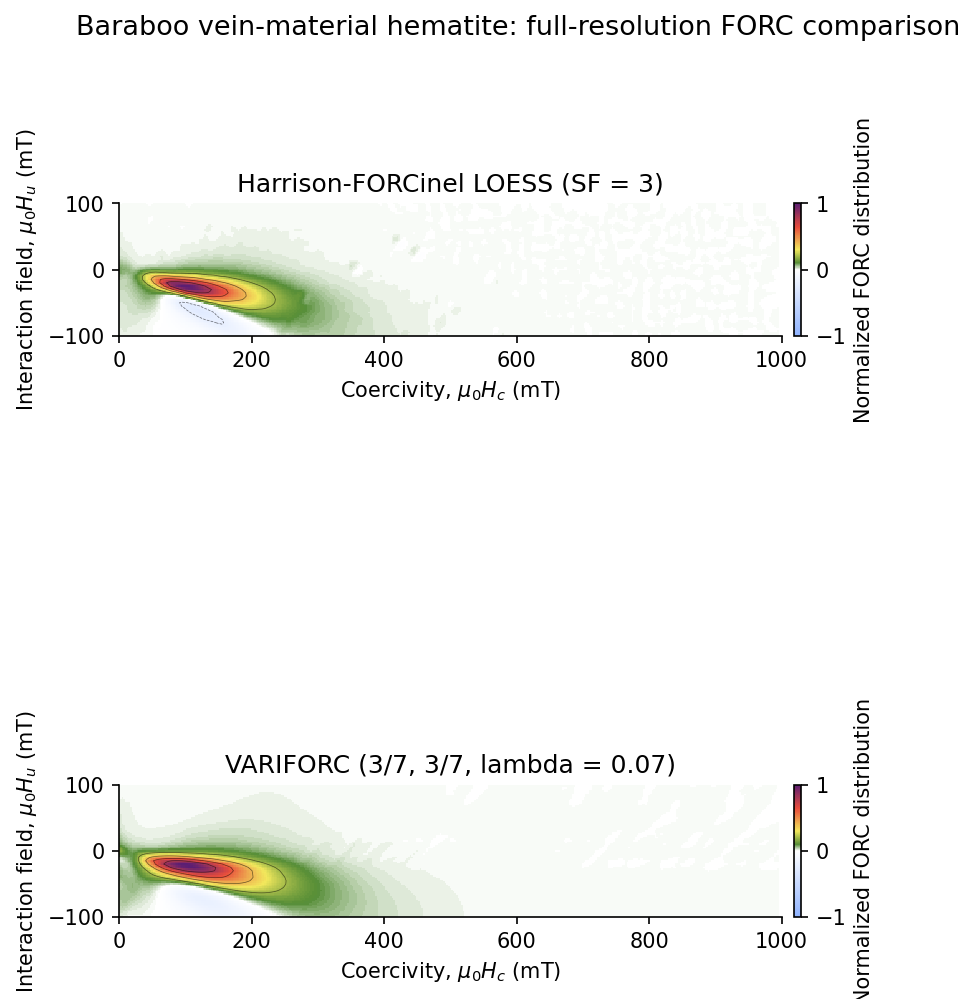

In [9]:
from scipy.interpolate import RegularGridInterpolator


def upsample_forc_result_for_display(result, factor=2):
    '''Linearly upsample rho for plotting without changing the fitted result.'''
    factor = int(factor)
    if factor <= 1:
        return result

    hc_axis = np.asarray(result.hc[0, :], dtype=float)
    hu_axis = np.asarray(result.hu[:, 0], dtype=float)
    hc_display = np.linspace(hc_axis[0], hc_axis[-1], (hc_axis.size - 1) * factor + 1)
    hu_display = np.linspace(hu_axis[0], hu_axis[-1], (hu_axis.size - 1) * factor + 1)
    hc_grid, hu_grid = np.meshgrid(hc_display, hu_display)

    interpolator = RegularGridInterpolator(
        (hu_axis, hc_axis),
        result.rho,
        method="linear",
        bounds_error=False,
        fill_value=np.nan,
    )
    rho_display = interpolator(np.column_stack([hu_grid.ravel(), hc_grid.ravel()]))
    rho_display = rho_display.reshape(hc_grid.shape)
    return replace(result, hc=hc_grid, hu=hu_grid, rho=rho_display)


display_upsample_factor = 2
forcme_display_dpi = 150
forcme_export_dpi = 600
loess_display = upsample_forc_result_for_display(loess_result, display_upsample_factor)
variforc_display = upsample_forc_result_for_display(variforc_result, display_upsample_factor)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(7, 7.5),
    dpi=forcme_display_dpi,
    constrained_layout=False,
)
fig.subplots_adjust(left=0.12, right=0.88, bottom=0.07, top=0.92, hspace=0.55)
_, _, loess_colorbar = forc.plot_forc(
    loess_display, ax=axes[0], normalize=True, percentile=100,
    hc_limits=(0, hc_plot_max), hu_limits=(-hu_plot_max, hu_plot_max)
)
axes[0].set_title("Harrison-FORCinel LOESS (SF = 3)")
_, _, variforc_colorbar = forc.plot_forc(
    variforc_display, ax=axes[1], normalize=True, percentile=100,
    hc_limits=(0, hc_plot_max), hu_limits=(-hu_plot_max, hu_plot_max)
)
axes[1].set_title("VARIFORC (3/7, 3/7, lambda = 0.07)")
for axis in axes:
    axis.set_aspect("equal", adjustable="box")

# Matplotlib sizes colorbars before the equal-aspect axes shrink. Reposition
# them after the final axes geometry is known so their heights match exactly.
fig.canvas.draw()
for axis, colorbar in zip(axes, [loess_colorbar, variforc_colorbar]):
    axis_position = axis.get_position()
    colorbar.ax.set_position([
        axis_position.x1 + 0.012,
        axis_position.y0,
        0.016,
        axis_position.height,
    ])
    colorbar.ax.set_in_layout(False)
fig.suptitle(
    "Baraboo vein-material hematite: full-resolution FORC comparison",
    fontsize=13,
)
print(
    f"Display: {forcme_display_dpi} dpi with {display_upsample_factor}x interpolation; "
    f"recommended PNG export: {forcme_export_dpi} dpi"
)
plt.show()

## 10. Inspect the actual VARIFORC smoothing

A parameter label such as “3/7” is incomplete because the local factors change with position. These maps show the regression half-widths actually used, in nominal field-step units. Near the central ridge, $s_b$ remains small to protect vertical resolution. Away from it, $s_b$ increases. The same transition around $H_c=0$ controls $s_c$ when a vertical ridge may be present.

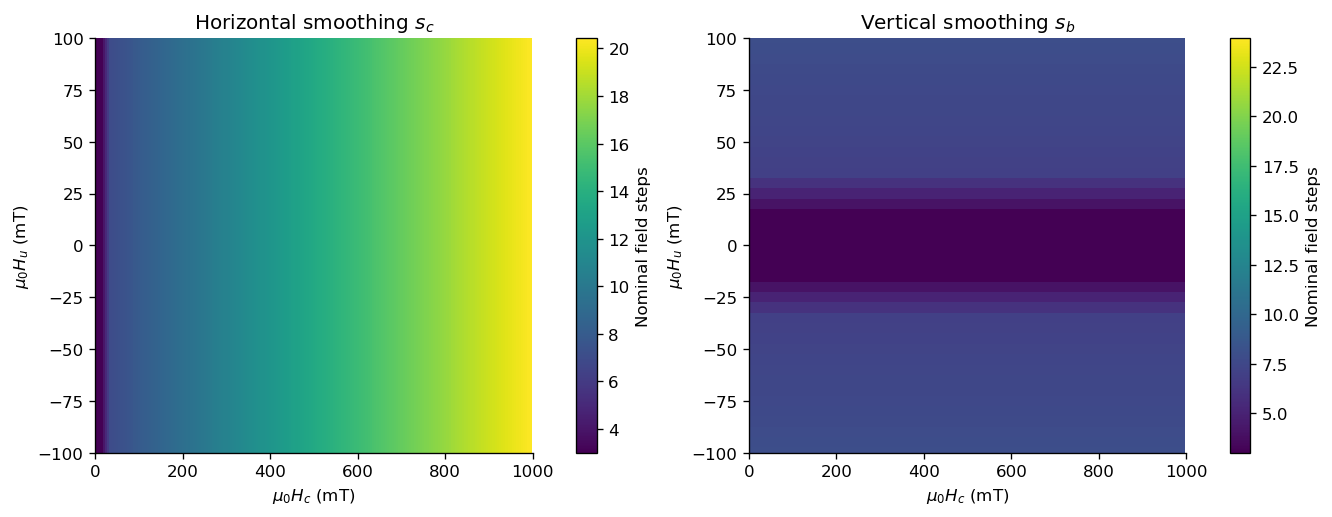

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for axis, values, title in zip(
    axes,
    [variforc_result.sc, variforc_result.sb],
    ["Horizontal smoothing $s_c$", "Vertical smoothing $s_b$"],
):
    image = axis.pcolormesh(
        variforc_result.hc * 1e3,
        variforc_result.hu * 1e3,
        values,
        shading="auto",
        cmap="viridis",
    )
    fig.colorbar(image, ax=axis, label="Nominal field steps")
    axis.set(xlabel="$\\mu_0H_c$ (mT)", ylabel="$\\mu_0H_u$ (mT)", title=title)
    axis.set_xlim(0, hc_plot_max)
    axis.set_ylim(-hu_plot_max, hu_plot_max)
plt.show()

## 11. Use uncertainty, not color alone

The default HC3 covariance estimate allows non-constant residual variance within a local fit. The diagnostic below plots $|\rho|/\delta\rho$. Egli (2013) recommends highlighting a signal-to-noise ratio near 3 as a rapid significance guide; exact thresholds also depend on effective degrees of freedom and the chosen confidence level.

Isolated cells above 3 are not automatically meaningful. Prefer spatially coherent regions, check whether they repeat under nearby smoothing parameters, and relate them back to the raw curves.

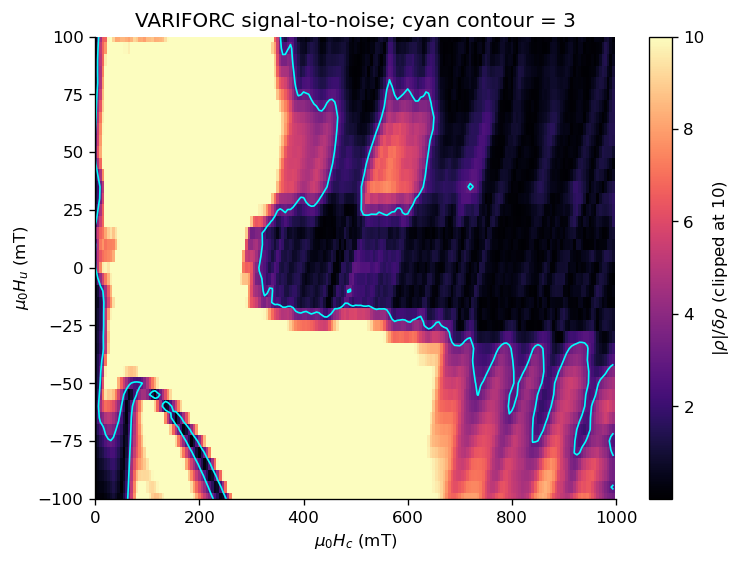

Cells with |rho|/error >= 3: 42.6%


In [11]:
snr = variforc_result.signal_to_noise
fig, ax = plt.subplots(figsize=(7, 5))
image = ax.pcolormesh(
    variforc_result.hc * 1e3,
    variforc_result.hu * 1e3,
    np.clip(snr, 0, 10),
    shading="auto",
    cmap="magma",
)
ax.contour(
    variforc_result.hc * 1e3,
    variforc_result.hu * 1e3,
    snr,
    levels=[3],
    colors="cyan",
    linewidths=1.0,
)
fig.colorbar(image, ax=ax, label="$|\\rho|/\\delta\\rho$ (clipped at 10)")
ax.set(
    xlabel="$\\mu_0H_c$ (mT)", ylabel="$\\mu_0H_u$ (mT)",
    title="VARIFORC signal-to-noise; cyan contour = 3",
    xlim=(0, hc_plot_max), ylim=(-hu_plot_max, hu_plot_max),
)
plt.show()

finite_snr = np.isfinite(snr)
print(f"Cells with |rho|/error >= 3: {100*np.mean(snr[finite_snr] >= 3):.1f}%")

## 12. Extract a reproducible profile

A horizontal profile at $H_u=0$ summarizes coercivity structure along the central ridge. `forc_profile` selects the nearest calculated grid row and returns unnormalized $\rho$. Report the requested cut, the actual grid spacing, the smoothing parameters, and whether the displayed profile was additionally smoothed. No extra profile smoothing is applied here.

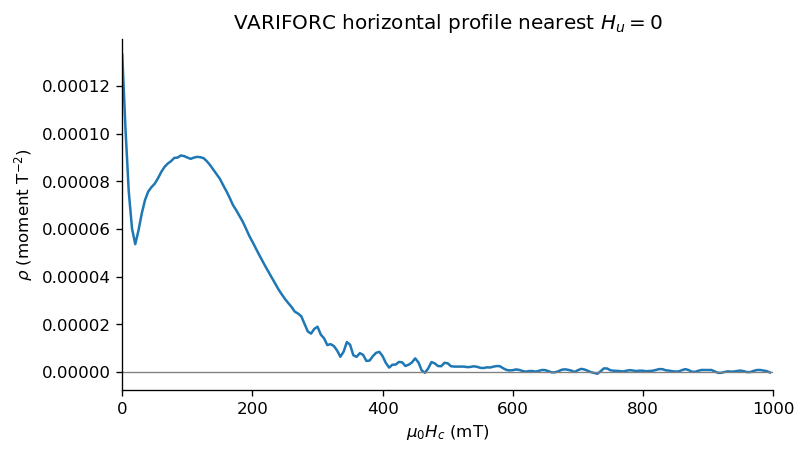

In [12]:
hc_profile, rho_profile = forc.forc_profile(variforc_result, axis="hc", value=0.0)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(hc_profile * 1e3, rho_profile, lw=1.5)
ax.axhline(0, color="0.5", lw=0.8)
ax.set(
    xlabel="$\\mu_0H_c$ (mT)",
    ylabel="$\\rho$ (moment T$^{-2}$)",
    title="VARIFORC horizontal profile nearest $H_u=0$",
    xlim=(0, hc_plot_max),
)
plt.show()

## 13. Reproducible one-call processing

After the individual decisions have been inspected, the same workflow can be reproduced with one call. Keep the arguments in an analysis script or notebook rather than relying on defaults alone.

In [13]:
one_call_output = forc.run_forc_pipeline(
    data_path,
    method="variforc",
    drift=True,
    drift_method="multiplicative",
    drift_fit="linear",
    drift_smoothing=2,
    endpoint_method="drop",
    endpoint_replace_n=1,
    do_lower_branch_subtract=False,
    sc0=3,
    sc1=7,
    sb0=3,
    sb1=7,
    lambda_c=0.07,
    lambda_b=0.07,
    output_step=1,
    error_method="hc3",
)
one_call = one_call_output["result"]

assert np.allclose(one_call.rho, variforc_result.rho, equal_nan=True)
print("The one-call result reproduces the staged calculation.")

The one-call result reproduces the staged calculation.


## 14. Process every supplied example

The same audited settings are now applied to **every file currently present** in `example_data/FORC` using FORCme's familiar batch-pipeline organization. Each file is read and conditioned independently; measurements are not stacked or averaged across specimens.

For each dataset, the notebook retains three explicit stages:

1. **Original FORCs** - measured moment-field curves exactly as parsed.
2. **Conditioned FORCs** - multiplicative calibration-drift correction, removal of the first and last point, and subtraction of a smooth coverage-aware baseline. At each field, the baseline uses the five lowest-reversal curves that contain a measurement there.
3. **Final FORC distribution** - variable, anisotropic local quadratic smoothing followed by the mixed second derivative.

The final calculation uses `output_step=1`, so every nominal output-grid position supported by the measurements is evaluated. This is the highest calculation-grid density available from the measured field increment. No display upsampling is used, because interpolation could make a plot look denser without adding scientific resolution. Final diagrams use FORCme's green-red version-2 colormap exactly: light blue for negative values, white at zero, and green-yellow-red-purple for positive values.

Lower-branch subtraction is not universally appropriate. It is applied here because this walkthrough explicitly demonstrates baseline removal; analyses intended to retain the uncentered magnetization surface should repeat the calculation with baseline subtraction disabled. The coverage-aware estimator is used instead of FORCme's first-FORC constant extension or FORCinel's potentially long quadratic extrapolation.

In [14]:
data_dir = data_path.parent
batch_outputs = forc.run_forc_pipeline(
    data_dir,
    mode="b",
    file_type="*",
    method="variforc",
    drift=True,
    drift_method="multiplicative",
    drift_fit="linear",
    drift_smoothing=2,
    endpoint_method="drop",
    endpoint_replace_n=1,
    do_lower_branch_subtract=True,
    lower_branch_curves=5,
    lower_branch_smoothing=2,
    sc0=3,
    sc1=7,
    sb0=3,
    sb1=7,
    lambda_c=0.07,
    lambda_b=0.07,
    output_step=1,
    error_method="hc3",
)

all_processing = {}
batch_rows = []
for output in batch_outputs:
    path = Path(output["input_path"])
    original = output["raw"]
    processed = output["processed"]
    result = output["result"]
    all_processing[path.name] = {
        "original": original,
        "processed": processed,
        "baseline_field": output["baseline_field"],
        "baseline_moment": output["baseline_moment"],
        "result": result,
    }
    finite_rho = np.isfinite(result.rho)
    finite_snr = np.isfinite(result.signal_to_noise)
    batch_rows.append({
        "sample": path.name,
        "FORCs": original.n_curves,
        "measurements": original.moment.size,
        "field step (mT)": 1e3 * result.parameters["field_step_T"],
        "rho grid": f"{result.rho.shape[0]} x {result.rho.shape[1]}",
        "finite rho cells": int(finite_rho.sum()),
        "median points/fit": float(np.nanmedian(result.point_count[result.point_count > 0])),
        "99th percentile |rho|": float(np.nanpercentile(np.abs(result.rho[finite_rho]), 99)),
        "cells with S/N >= 3 (%)": float(100 * np.mean(result.signal_to_noise[finite_snr] >= 3)),
    })

batch_summary = pd.DataFrame(batch_rows).set_index("sample")
display(batch_summary)

assert len(all_processing) == len(batch_outputs)
assert all(np.isfinite(item["result"].rho).any() for item in all_processing.values())

,FORCs,measurements,field step (mT),rho grid,finite rho cells,median points/fit,99th percentile |rho|,cells with S/N >= 3 (%)
sample,,,,,,,,
AX21-7-sc_FORC,124,9214,2.963490,125 x 47,4746,448.0,0.000020,34.555415
AX21-7-sub2_FORC,104,8164,4.938620,105 x 54,4235,434.0,0.000076,40.000000
BD2-2r_FORC,104,8164,4.938985,105 x 54,4235,434.0,0.000835,49.988194
MA1-5-r_FORC.txt,160,24898,3.000000,161 x 134,12661,660.0,0.000065,55.027249
MA1-OX-r FORC.txt,333,105919,2.001136,334 x 263,53387,1187.0,0.000671,57.180587
MC7-1r_FORC,104,8164,4.938720,105 x 54,4235,434.0,0.000050,33.341204
SJ1-4_forc.txt,140,17960,2.001271,141 x 100,9148,571.0,0.000073,26.759948
TH1-2-r.forc,76,5504,5.000000,76 x 60,2790,390.0,0.000150,57.096774
WS3-5-r.forc,76,5504,5.000000,76 x 60,2790,390.0,0.000163,48.530466


### Per-dataset processing panels

Each figure below uses the same ordering. The middle panel is shown immediately before local regression, so its changes relative to the raw curves come only from the documented calibration, endpoint, and coverage-aware baseline operations. It should remain centered across the full measured field range; a systematic high-field rise would indicate unsupported baseline extrapolation. Smoothing enters in the final panel through the VARIFORC local quadratic fit. Final panels are independently normalized to their 99th-percentile absolute amplitude; consult the table above for quantitative amplitude comparisons.

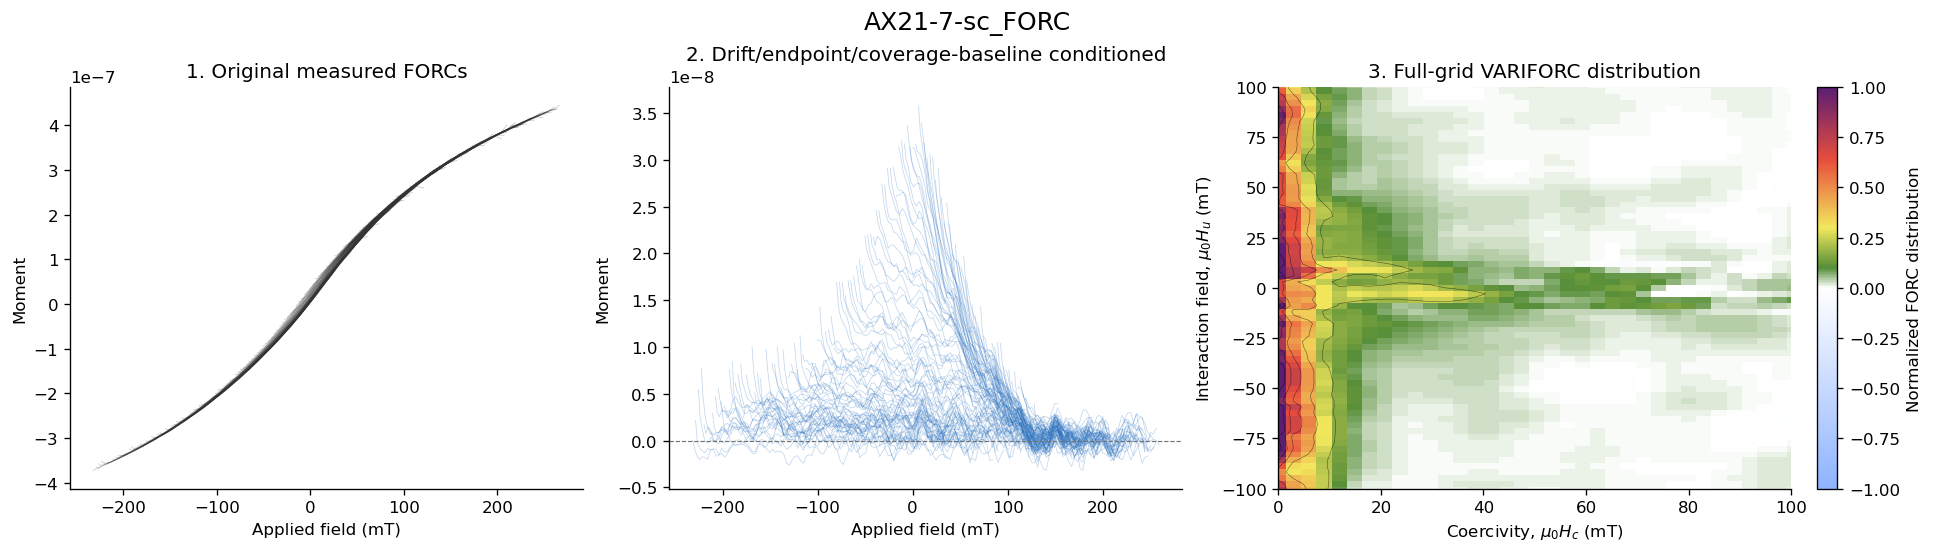

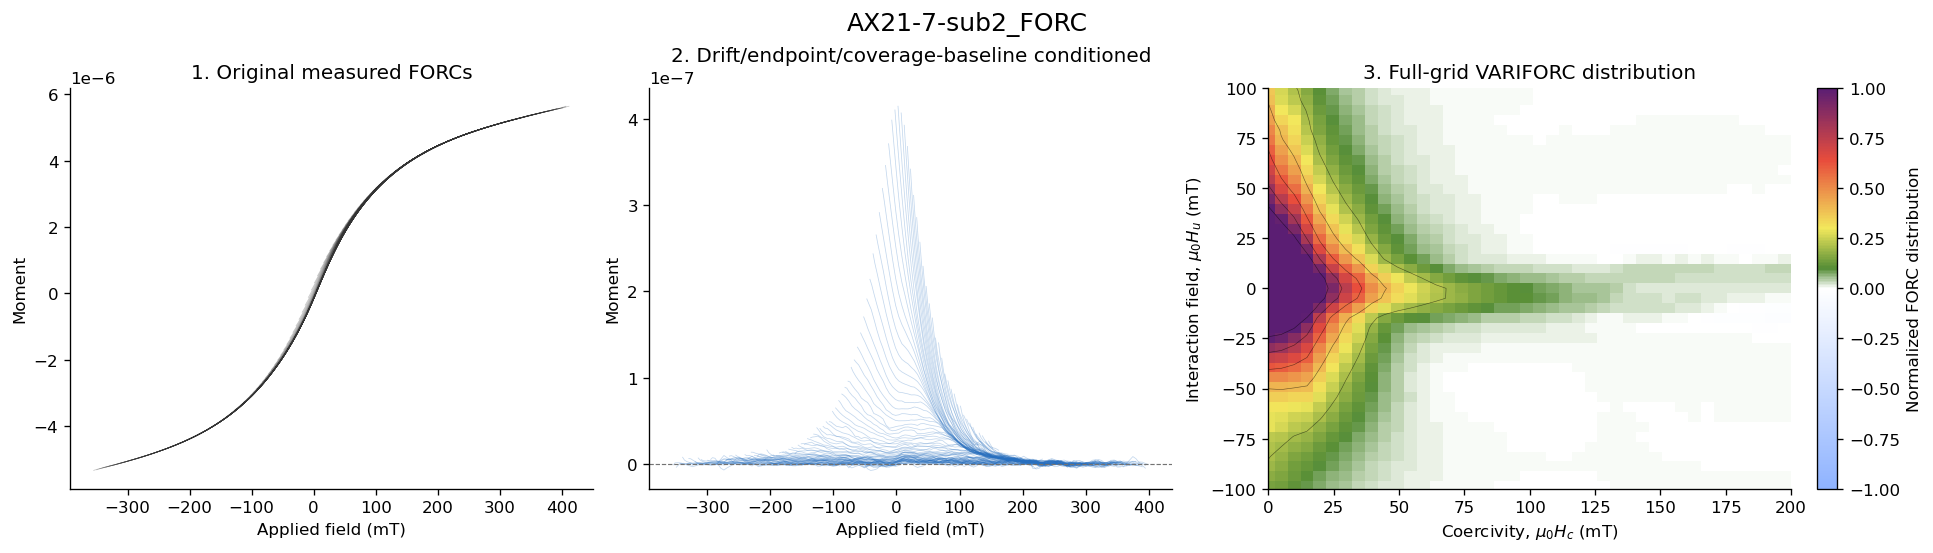

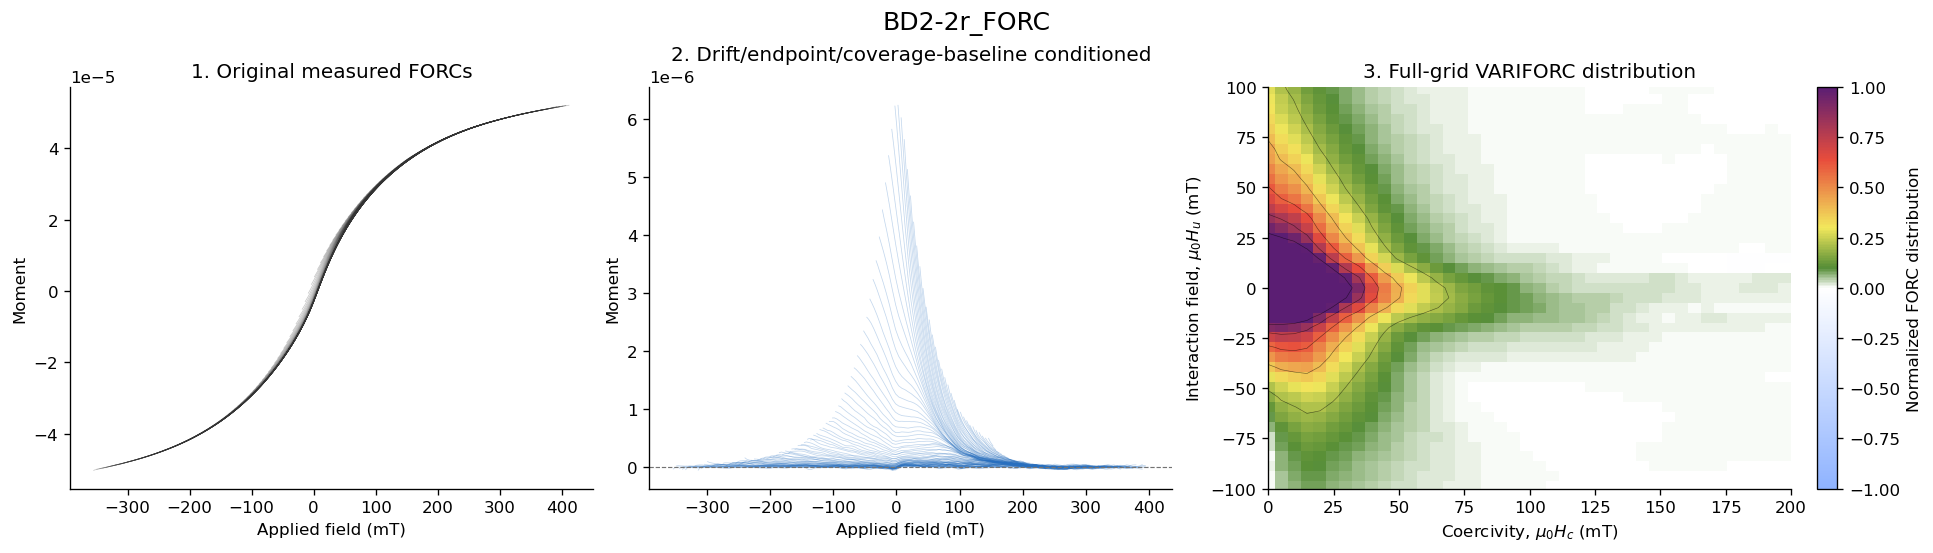

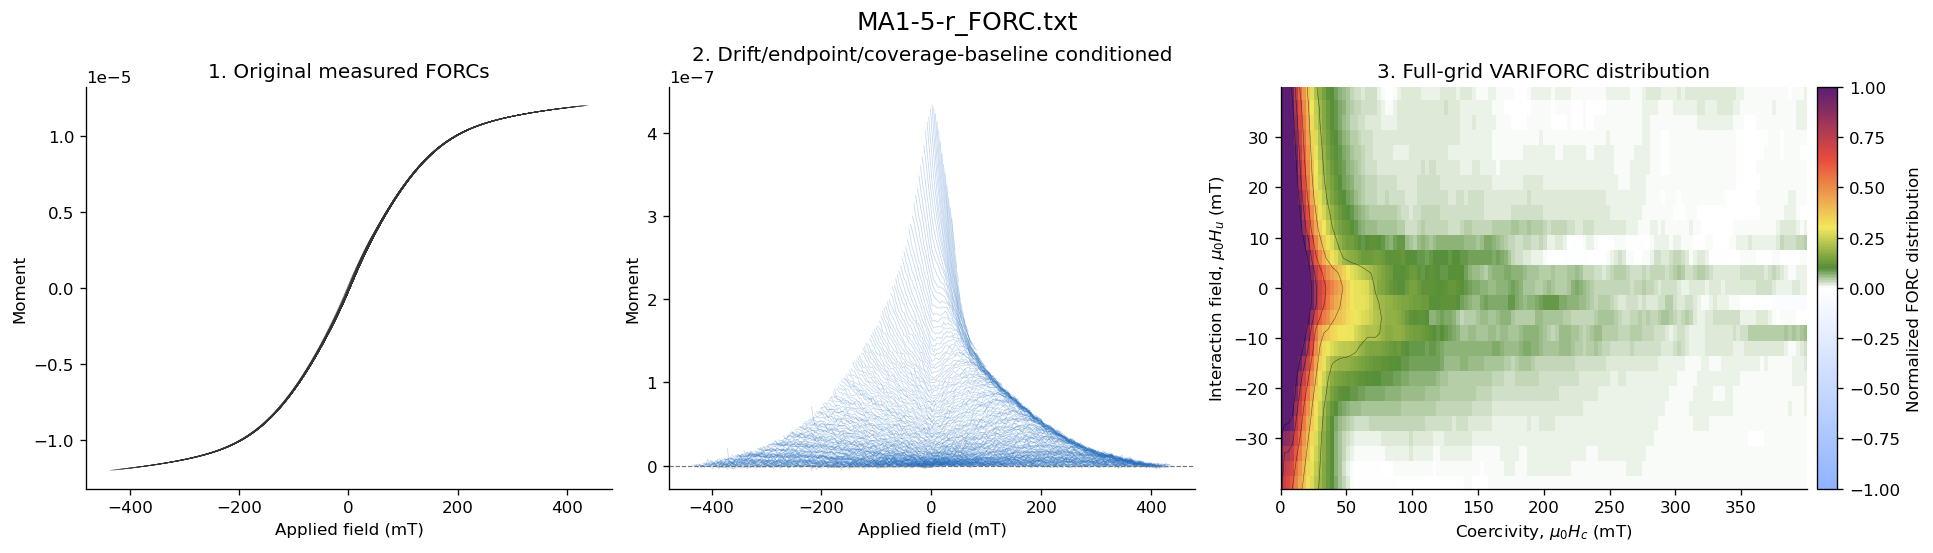

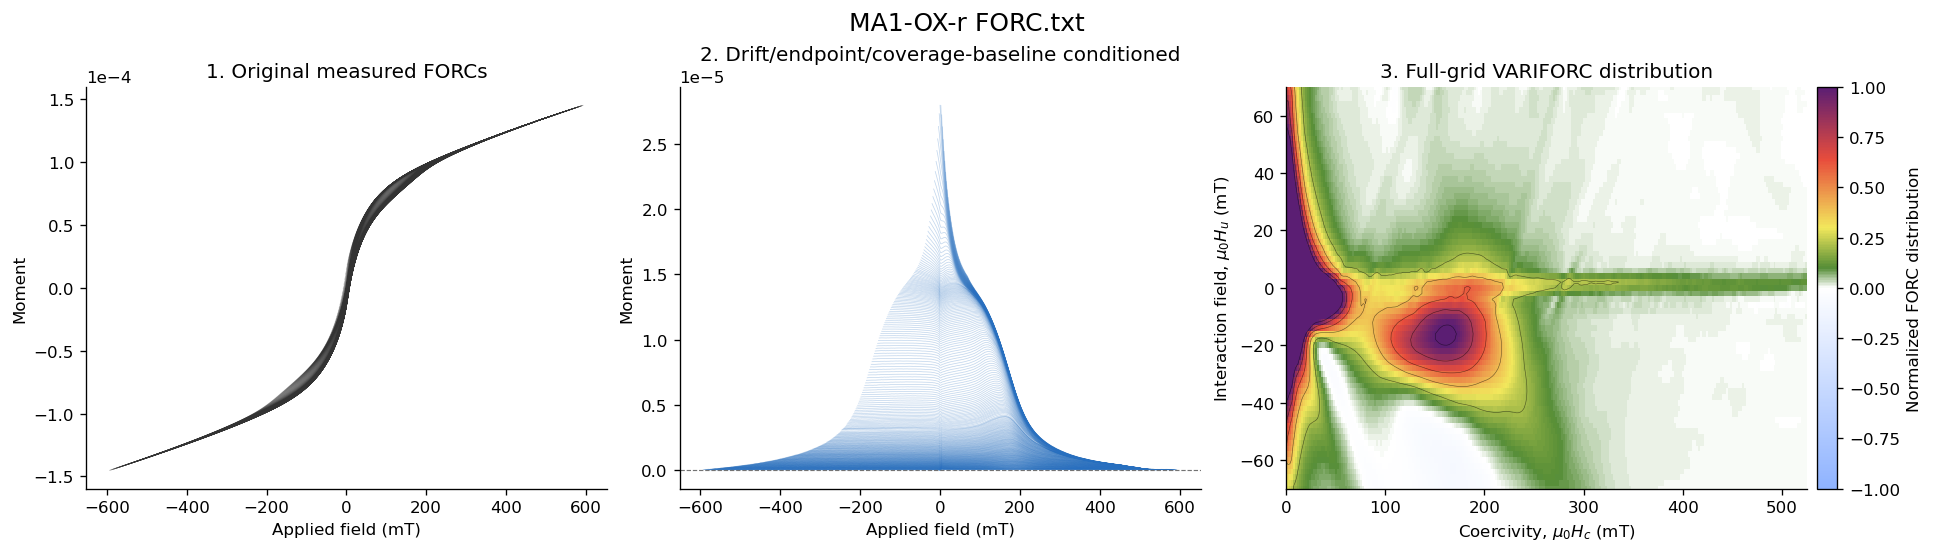

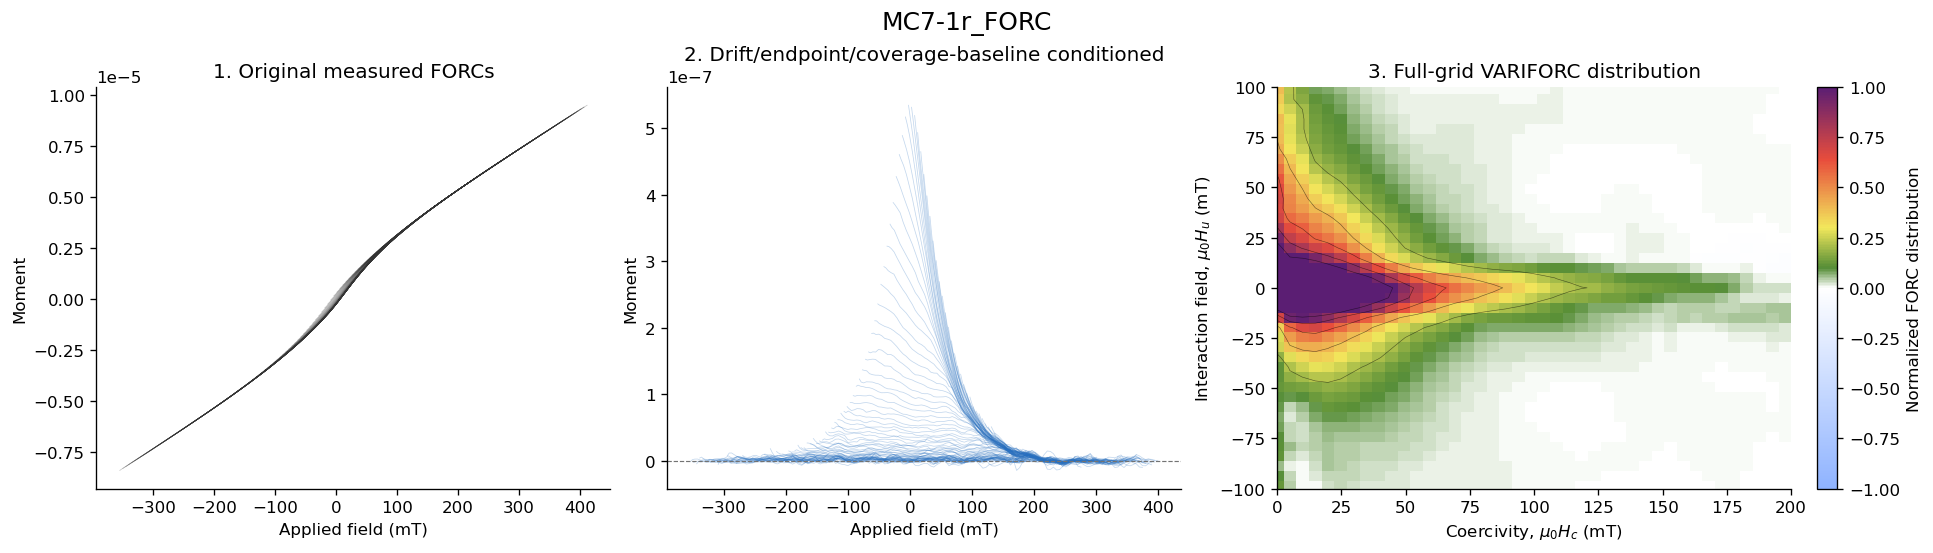

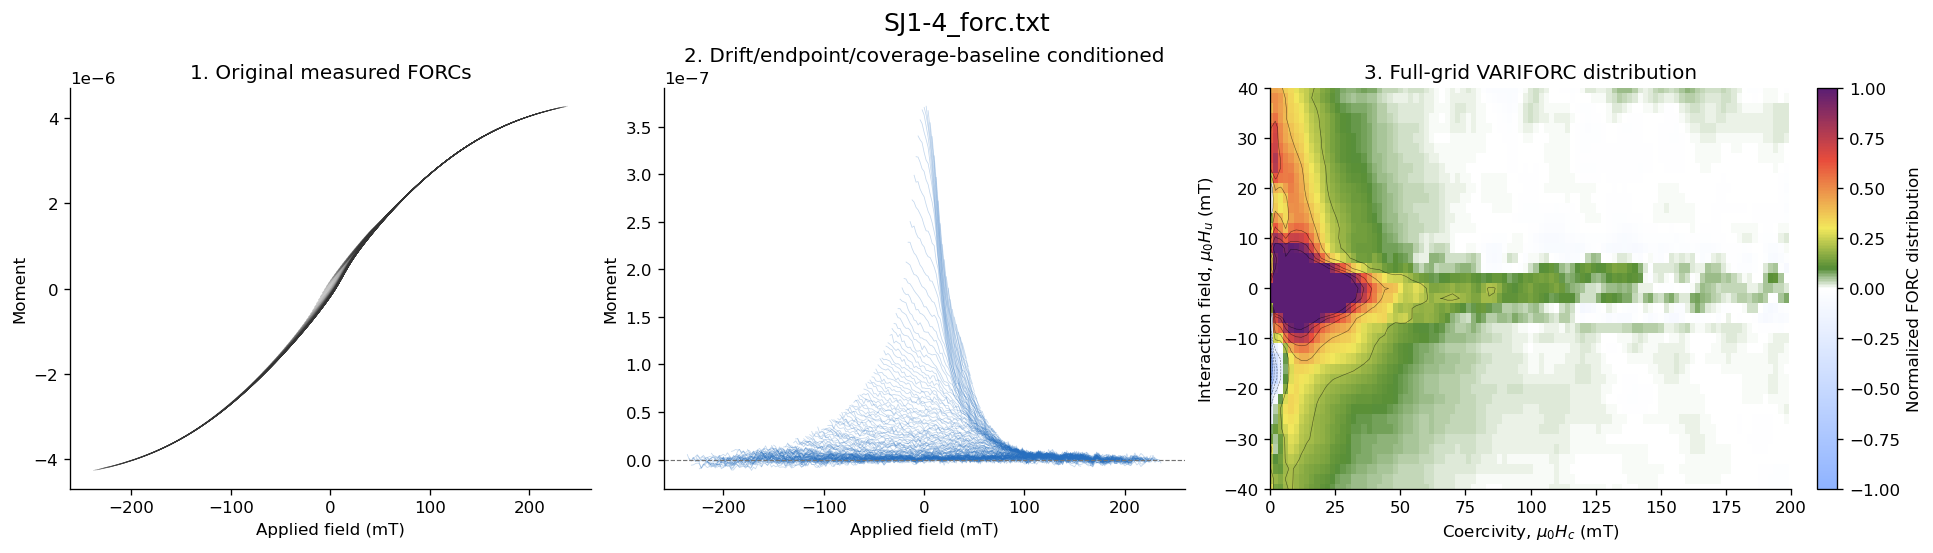

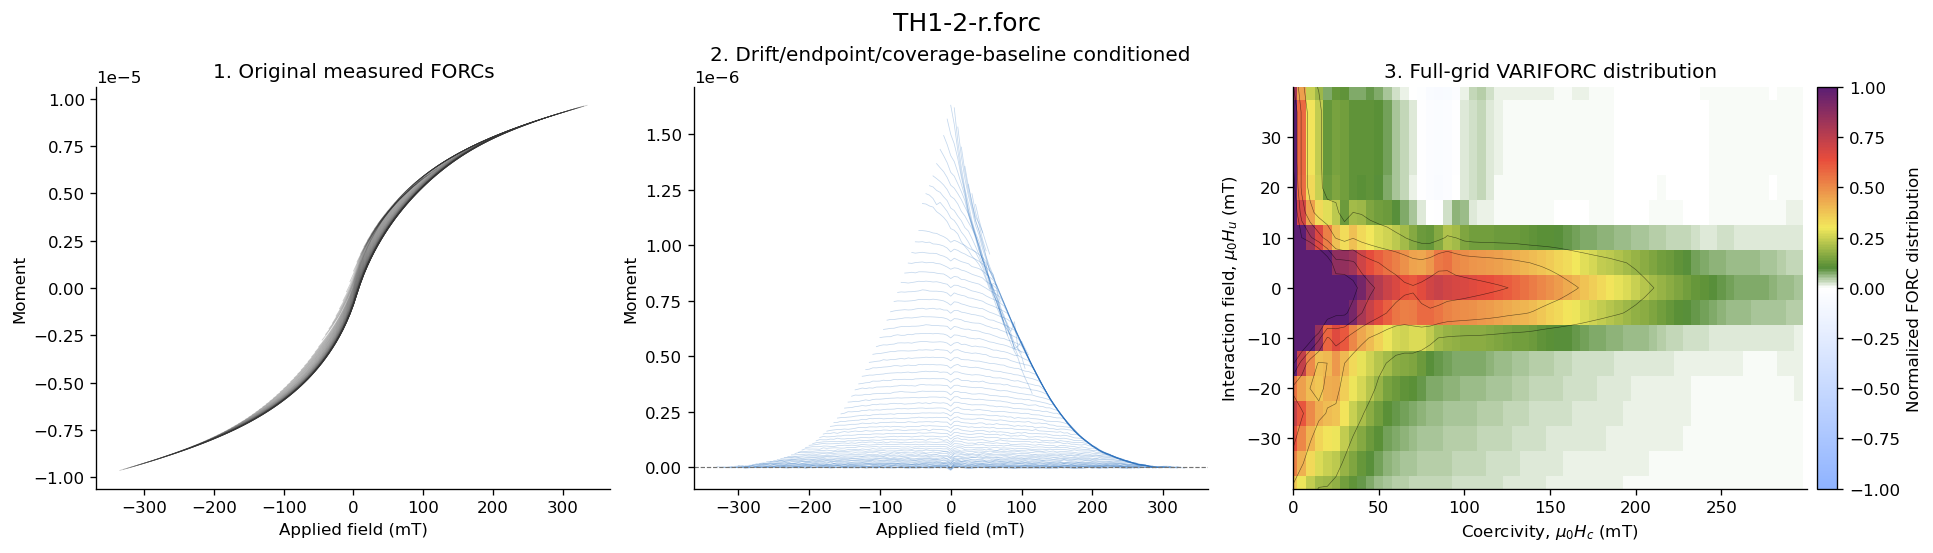

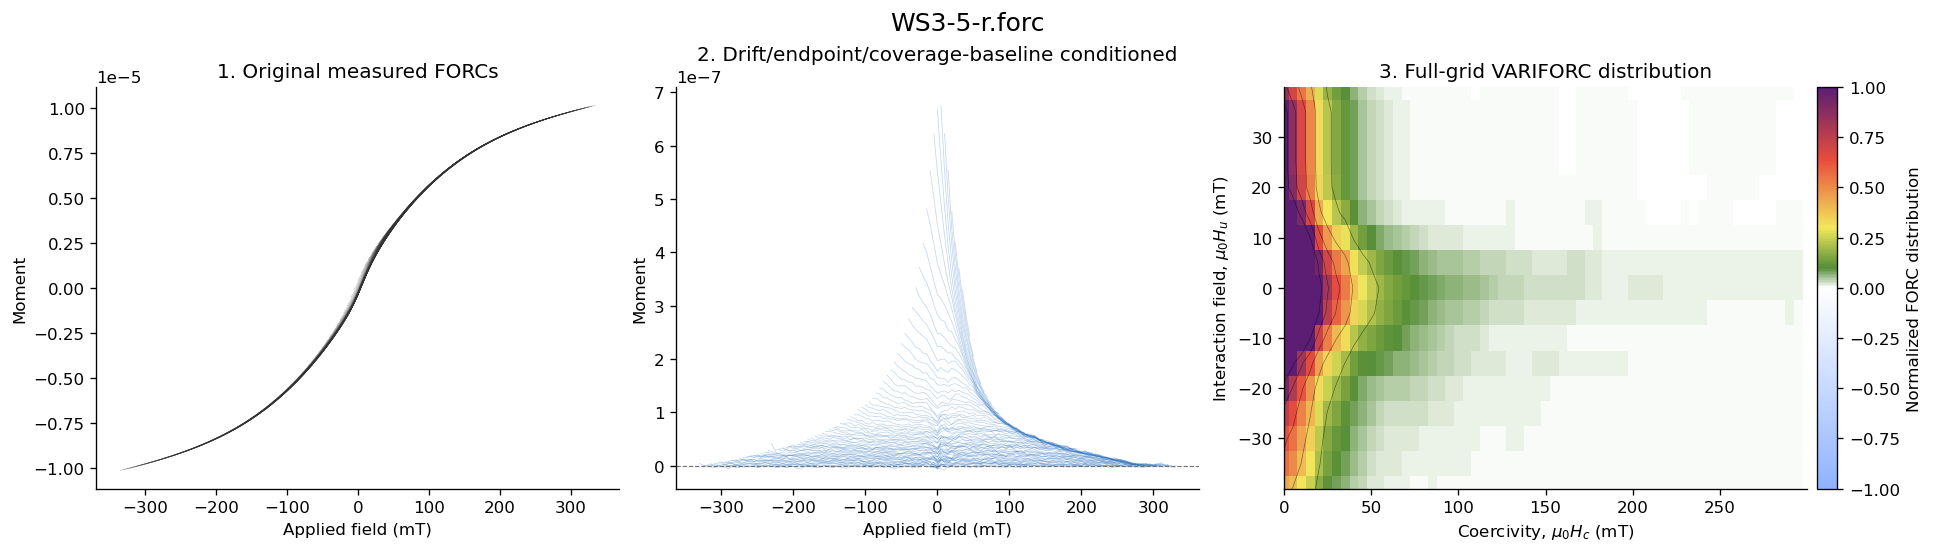

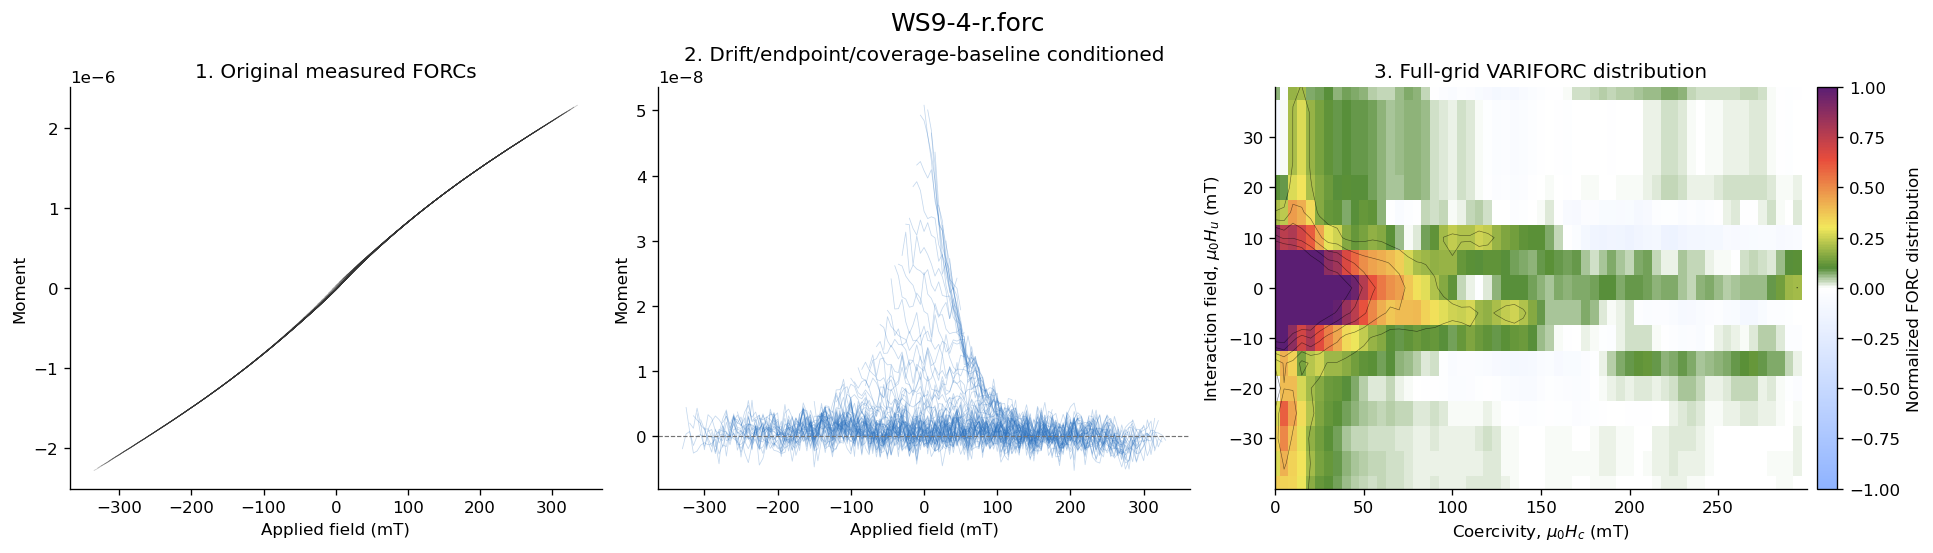

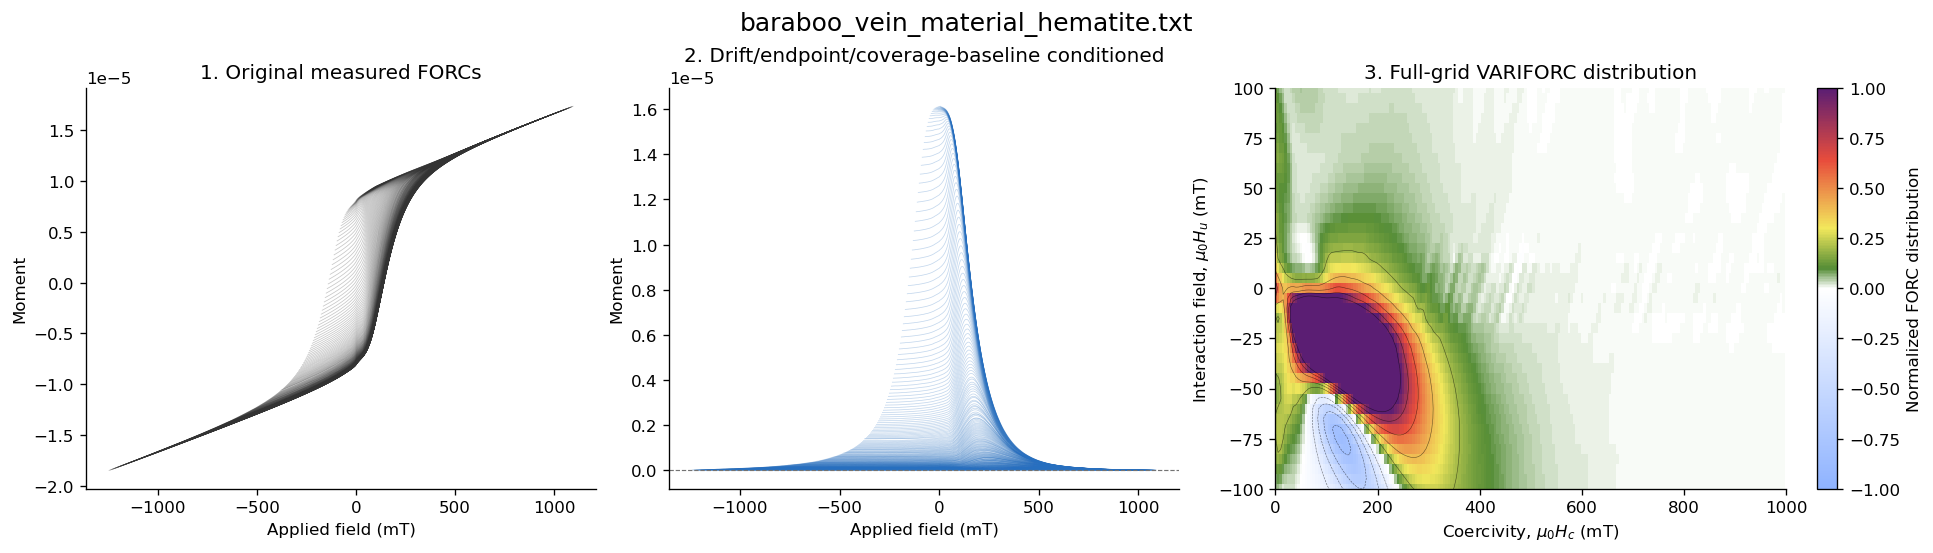

In [15]:
def plot_curve_family(axis, data, color, alpha=0.28):
    '''Plot every measured curve with a light line so dense runs remain legible.'''
    for curve_number in range(data.n_curves):
        select = data.curve == curve_number
        axis.plot(
            data.field[select] * 1e3,
            data.moment[select],
            color=color,
            linewidth=0.45,
            alpha=alpha,
        )
    axis.set_xlabel("Applied field (mT)")
    axis.set_ylabel("Moment")
    axis.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))


for sample_name, item in all_processing.items():
    original = item["original"]
    processed = item["processed"]
    result = item["result"]

    figure, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    plot_curve_family(axes[0], original, color="0.20")
    axes[0].set_title("1. Original measured FORCs")

    plot_curve_family(axes[1], processed, color="#276FBF")
    axes[1].axhline(0, color="0.45", linewidth=0.7, linestyle="--")
    axes[1].set_title("2. Drift/endpoint/coverage-baseline conditioned")

    hc_header = forc.metadata_value(result.data.metadata, "Hc2")
    hu_header = forc.metadata_value(result.data.metadata, "Hb2")
    hc_max = 1e3 * hc_header if hc_header is not None else float(np.nanmax(result.hc) * 1e3)
    hu_max = abs(1e3 * hu_header) if hu_header is not None else float(np.nanmax(np.abs(result.hu)) * 1e3)
    forc.plot_forc(
        result,
        ax=axes[2],
        normalize=True,
        percentile=99,
        hc_limits=(0, hc_max),
        hu_limits=(-hu_max, hu_max),
    )
    axes[2].set_title("3. Full-grid VARIFORC distribution")

    figure.suptitle(sample_name, fontsize=15)
    plt.show()

## 15. Interpretation and reporting checklist

Before interpreting domains, interactions, or mineral components:

- Confirm the measurement and moment units from the source header.
- Show representative raw curves and the calibration series.
- If a high-field slope is removed from displayed curves, report the fitted field interval, slope, and moment normalization; distinguish this linear background correction from the FORC derivative itself.
- State the drift model, endpoint treatment, and any rejected measurements.
- Report the algorithm and all smoothing parameters. For VARIFORC this includes $s_{c,0}$, $s_{c,1}$, $s_{b,0}$, $s_{b,1}$, $\lambda_c$, $\lambda_b$, and any ridge offset.
- Distinguish display normalization and interpolation from the scientific regression.
- Inspect point-count and signal-to-noise support, especially at boundaries.
- Repeat the calculation over a reasonable neighborhood of smoothing settings. A feature that exists only for one setting is not robust.
- Do not compare absolute $\rho$ values between software packages until their factor-of-two convention and normalization are confirmed.

### References

- Harrison, R. J., and J. M. Feinberg (2008), *FORCinel: An improved algorithm for calculating first-order reversal curve distributions using locally weighted regression smoothing*, **G3**, 9, Q05016. https://doi.org/10.1029/2008GC001987
- Egli, R. (2013), *VARIFORC: An optimized protocol for calculating non-regular first-order reversal curve (FORC) diagrams*, **Global and Planetary Change**, 110, 302-320. https://doi.org/10.1016/j.gloplacha.2013.08.003
- Heslop, D., and A. P. Roberts (2012), Estimation and propagation of uncertainties associated with first-order reversal curve distributions, *Journal of Geophysical Research*, 117, B11101.
- Brown, M. (2026), *FORCme: Application of machine code and adaptive smoothing within Python for the rapid processing of First Order Reversal Curves*, version 1.0.0. Workflow naming and colormaps used under the MIT License.